## Подготовка данных 

**1. Загружаем датасет Титаник**

In [46]:
import pandas as pd
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
display(train.head())
display(test.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


**2. Конкатенируем train и test в один dataframe**

In [47]:
titanic_df = pd.concat([train, test], axis="index", ignore_index=True)
display(titanic_df.head())
display(titanic_df.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


Мы видим, что столбец Survived принял значения NaN там, где значений раньше небыло.

**3. Приводим столбцы к конкретным типам и проверяем**

In [48]:
titanic_df["Survived"] = titanic_df["Survived"].astype("category")
titanic_df["Pclass"] = titanic_df["Pclass"].astype("category")
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
display(titanic_df.dtypes)

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
dtype: object

## Анализ таблицы

**1. Базовая статистика таблицы**

In [49]:
titanic_df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,1309.000000,891.0,1309.0,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307
unique,NaN,2.0,3.0,1307,2,NaN,NaN,NaN,929,NaN,186,3
top,NaN,0.0,3.0,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S
freq,NaN,549.0,709.0,2,843,NaN,NaN,NaN,11,NaN,6,914
mean,655.000000,NaN,NaN,NaN,NaN,29.881138,0.498854,0.385027,NaN,33.295479,NaN,NaN
std,378.020061,NaN,NaN,NaN,NaN,14.413493,1.041658,0.865560,NaN,51.758668,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,328.000000,NaN,NaN,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,655.000000,NaN,NaN,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,982.000000,NaN,NaN,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


В каком классе было больше всего пассажиров?

In [50]:
most_popular_pclass = titanic_df["Pclass"].value_counts().idxmax()
print(f"Больше всего пассажиров было в классе {most_popular_pclass}")

Больше всего пассажиров было в классе 3


Ответ: Больше всего пассажиров было в классе 3

**2. Группировка таблицы в два уровня: класс и пол, по среднему значению возраста.**

In [51]:
grouped_mean_age = titanic_df.groupby(["Pclass", "Sex"], observed=False)["Age"].mean()
display(grouped_mean_age)

Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

Кто из возможных комбинаций самый юный, кто самый взрослый? Насколько отличаются эти значения?

In [52]:
min_age = grouped_mean_age.min()
max_age = grouped_mean_age.max()
age_dif = max_age - min_age
print(f"Самой юной является комбинация {grouped_mean_age.idxmin()[1]} из класса {grouped_mean_age.idxmin()[0]} со значением {min_age:.2f}")
print(f"Самой взрослой является комбинация {grouped_mean_age.idxmax()[1]} из класса {grouped_mean_age.idxmax()[0]} со значением {max_age:.2f}")
print(f"Разница в значениях составляет {age_dif:.2f}")

Самой юной является комбинация female из класса 3 со значением 22.19
Самой взрослой является комбинация male из класса 1 со значением 41.03
Разница в значениях составляет 18.84


Ответ:\
Самой юной является комбинация female из класса 3 со значением 22.19\
Самой взрослой является комбинация male из класса 1 со значением 41.03\
Разница в значениях составляет 18.84

**3. Отбираем выживших пассажиров с фамилией, начинающейся на “K”. Сортируем их по убыванию стоимости билета.** 

In [53]:
survivors = titanic_df[(titanic_df["Survived"] == 1) & (titanic_df["Name"].str.startswith("K"))]
survivors_sorted = survivors.sort_values(["Fare"], ascending=False)
display(survivors_sorted)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
621,622,1.0,1,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1,0,11753,52.5542,D19,S
457,458,1.0,1,"Kenyon, Mrs. Frederick R (Marion)",female,NaN,1,0,17464,51.8625,D21,S
316,317,1.0,2,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1,0,244367,26.0000,NaN,S
184,185,1.0,3,"Kink-Heilmann, Miss. Luise Gretchen",female,4.0,0,2,315153,22.0250,NaN,S
706,707,1.0,2,"Kelly, Mrs. Florence ""Fannie""",female,45.0,0,0,223596,13.5000,NaN,S
691,692,1.0,3,"Karun, Miss. Manca",female,4.0,0,1,349256,13.4167,NaN,C
303,304,1.0,2,"Keane, Miss. Nora A",female,NaN,0,0,226593,12.3500,E101,Q
300,301,1.0,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
573,574,1.0,3,"Kelly, Miss. Mary",female,NaN,0,0,14312,7.7500,NaN,Q


Кто заплатил больше всех? Кто меньше всех?

In [54]:
rich_survivor = survivors_sorted["Name"].iloc[0]
poor_survivor = survivors_sorted["Name"].iloc[-1]
print(f"Самый дорогой билет у {rich_survivor}")
print(f"Самый дешевый билет у {poor_survivor}")

Самый дорогой билет у Kimball, Mr. Edwin Nelson Jr
Самый дешевый билет у Kelly, Miss. Mary


Ответ:\
Самый дорогой билет у Kimball, Mr. Edwin Nelson Jr\
Самый дешевый билет у Kelly, Miss. Mary

**4. Определяем какое максимальное количество родных было с выжившим пассажиром**

In [55]:
all_survived = titanic_df[titanic_df["Survived"] == 1]
max(all_survived["SibSp"] + all_survived["Parch"])

6

Ответ:\
Максимальное количество родных с выжившим пассажиром: 6

**5. Считаем среднюю стоимость билета пассажиров, для которых указана каюта и для тех, у кого она не указана, и во сколько раз они отличаются**

In [56]:
with_cabin_mean = titanic_df[titanic_df["Cabin"].notna()]["Fare"].mean()
without_cabin_mean = titanic_df[titanic_df["Cabin"].isna()]["Fare"].mean()
print(f"Средняя стоимость билета для пассажира с указанной каютой: {with_cabin_mean:.3f}")
print(f"Средняя стоимость билета для пассажира без указанной каюты: {without_cabin_mean:.3f}")
print(f"Разница в стоимости билетов в {with_cabin_mean / without_cabin_mean:.3f} раз")

Средняя стоимость билета для пассажира с указанной каютой: 81.929
Средняя стоимость билета для пассажира без указанной каюты: 19.133
Разница в стоимости билетов в 4.282 раз


Ответ:\
Средняя стоимость билета для пассажира с указанной каютой: 81.929\
Средняя стоимость билета для пассажира без указанной каюты: 19.133\
Разница в стоимости билетов в 4.282 раз

## Визуализация

Строим 10 графиков по данным датасета (5 интерактивных, 1 - 3D)
1. Scatter plot (interactive)
2. Linear plot
3. Histogram (interactive)
4. Bar chart (interactive)
5. Horizontal bar chart
6. Pie chart (interactive)
7. Box chart
8. Sunburst chart (interactive)
9. 3D Scatter plot
10. Histogram

Импорт необходимых библиотек

In [57]:
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

**1. Scatter plot (interactive)**\
Соотношение возраста и стоимости билета

In [58]:
fig = px.scatter(data_frame=titanic_df, x="Age", y="Fare", opacity=0.5, title="Age and fare ratio")
fig.show()

**2. Linear plot**\
Соотношение класса билета и цены

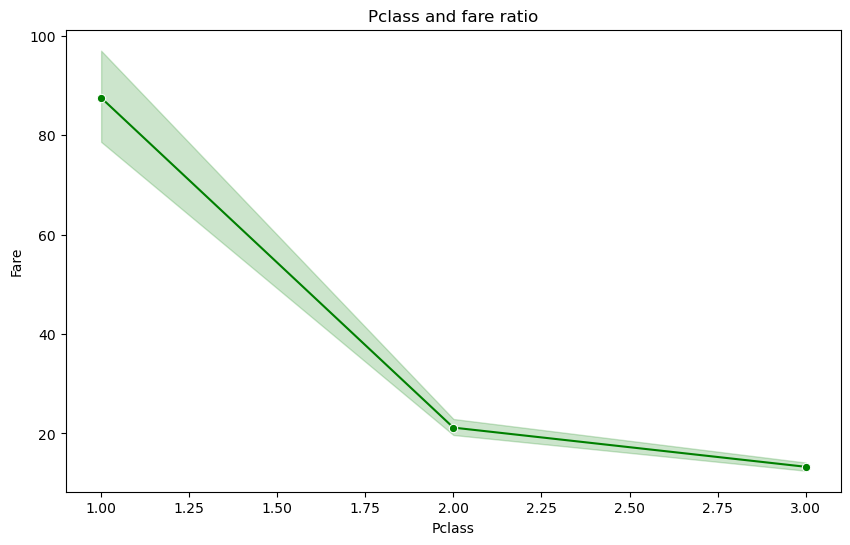

In [59]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=titanic_df, x="Pclass", y="Fare", marker="o", linestyle="-", color="green")
plt.title("Pclass and fare ratio")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

**3. Histogram(interactive)**\
Распределение цены билетов

In [60]:
fig = px.histogram(data_frame=titanic_df, x="Fare", color="Survived", title="Fare distribution of all passengers")
fig.show()

/usr/lib/python3/dist-packages/plotly/express/_core.py:1971: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**4. Bar chart(interactive)**\
Количество погибших и выживших по полу

In [61]:
survival_counts_by_gender = titanic_df.groupby(["Survived", "Sex"], observed=False).size().reset_index(name="Count")

fig = px.bar(survival_counts_by_gender, x="Sex", y="Count", color="Survived", barmode="group", title="Gender survival ratio")
fig.show()

/usr/lib/python3/dist-packages/plotly/express/_core.py:1971: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**5. Horizontal bar chart**\
Количество погибших и выживших по классам

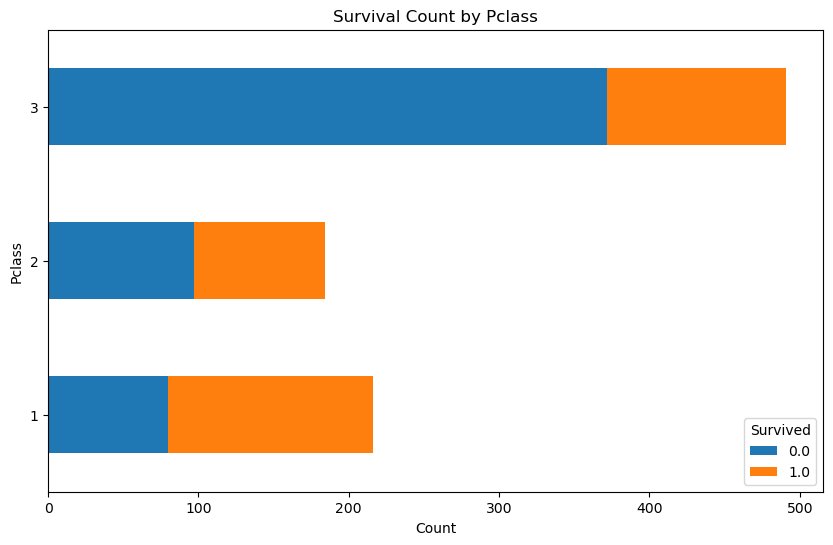

In [63]:
pclass_survival = titanic_df.groupby(["Pclass", "Survived"], observed=False).size().unstack()
pclass_survival.plot(kind="barh", stacked=True, figsize=(10, 6))
plt.title("Survival Count by Pclass")
plt.xlabel("Count")
plt.ylabel("Pclass")
plt.show()

**6. Pie chart(interactive)**\
Соотношение выживших и погибших

In [65]:
survived_not_na = titanic_df[titanic_df["Survived"].notna()]
fig = px.pie(survived_not_na, names="Survived", title="Survival Distribution")
fig.show()

**7. Box chart**\
Соотношение цены билета и пола

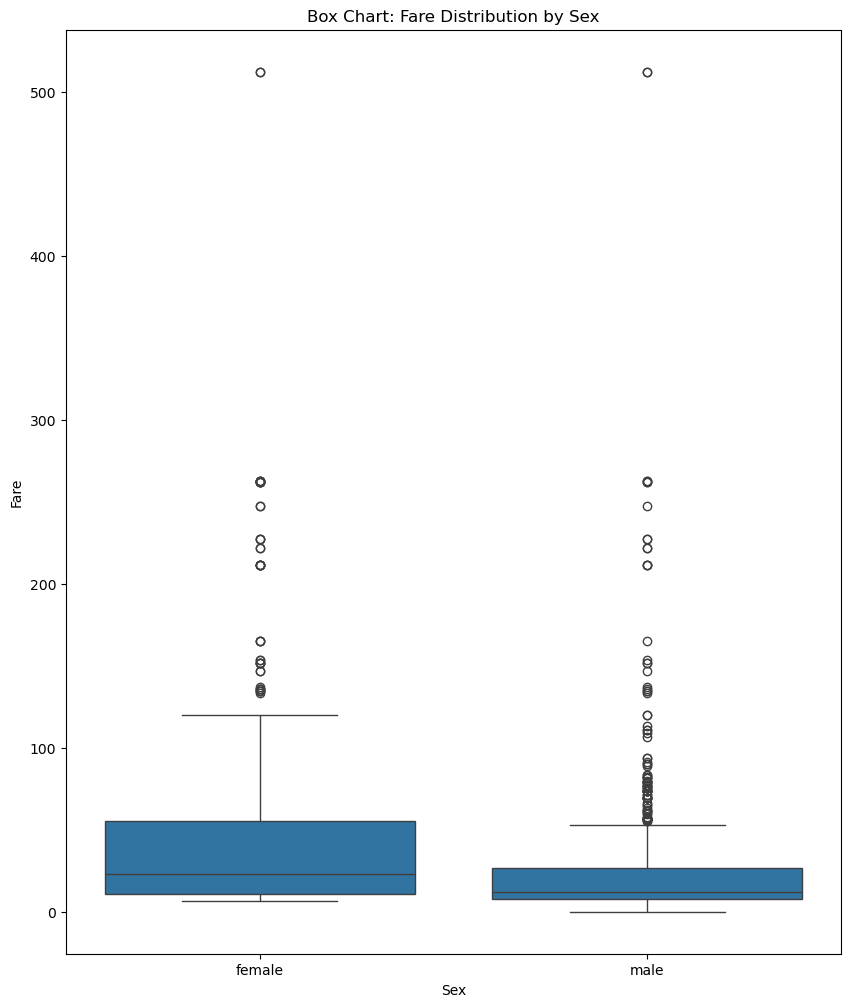

In [66]:
plt.figure(figsize=(10, 12))
sns.boxplot(data=titanic_df, x="Sex", y="Fare")
plt.title("Fare Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Fare")
plt.show()

**8. Sunburst chart(interactive)**\
Распределение выживаемости, пола и класса

In [67]:
fig = px.sunburst(survived_not_na, path=["Survived", "Sex", "Pclass"], title="Survival, Sex, and Pclass Distribution")
fig.show()

/usr/lib/python3/dist-packages/plotly/express/_core.py:1626: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/lib/python3/dist-packages/plotly/express/_core.py:1626: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/lib/python3/dist-packages/plotly/express/_core.py:1626: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**9. 3D Scatter plot**\
Распределение возраста, цены билета и класса

In [68]:
fig = px.scatter_3d(titanic_df, x="Age", y="Fare", z="Pclass", color="Survived", title="Age, Fare, and Pclass Distribution")
fig.show()

/usr/lib/python3/dist-packages/plotly/express/_core.py:1971: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**10. Histogram**\
Распределение возрастов

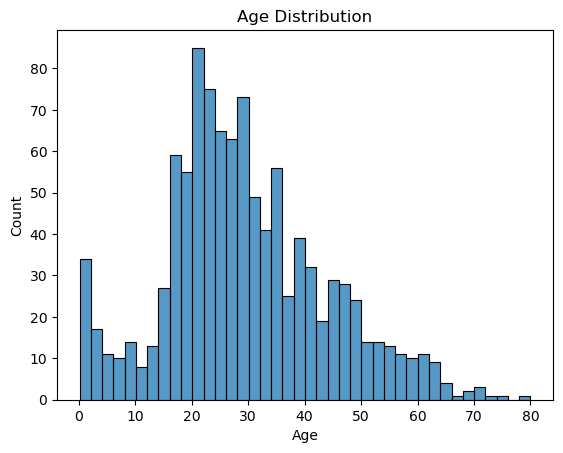

In [ ]:
sns.histplot(titanic_df["Age"].dropna(), bins=40)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()